In [21]:
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("train.csv")
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [4]:
imputer_median = SimpleImputer(strategy="median")
df["Age"] = imputer_median.fit_transform(df[["Age"]])

In [9]:
imputer_modus = SimpleImputer(strategy="most_frequent")  # ← ganti jadi imputer_modus
df["Embarked"] = imputer_modus.fit_transform(df[["Embarked"]]).ravel()

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     891 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.8 KB


In [11]:
df.drop(columns=["Cabin"], inplace = True)

In [16]:
df["Sex"] = df["Sex"].map({"male": 0, "female":1})
df["Embarked"] = df["Embarked"].map({"S": 0, "C": 1, "Q": 2})
df.drop(columns=["Name", "Ticket", "PassengerId"], inplace=True)

In [19]:
print(df.isnull().sum())
print(df.head())
df.to_csv("train.csv",index=False)

Survived      0
Pclass        0
Sex         891
Age           0
SibSp         0
Parch         0
Fare          0
Embarked    891
dtype: int64
   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked
0         0       3  NaN  22.0      1      0   7.2500       NaN
1         1       1  NaN  38.0      1      0  71.2833       NaN
2         1       3  NaN  26.0      0      0   7.9250       NaN
3         1       1  NaN  35.0      1      0  53.1000       NaN
4         0       3  NaN  35.0      0      0   8.0500       NaN


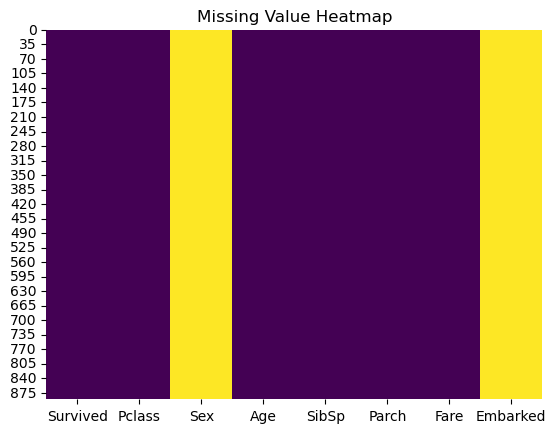

In [22]:
df =pd.read_csv("train.csv")
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Value Heatmap")
plt.show()

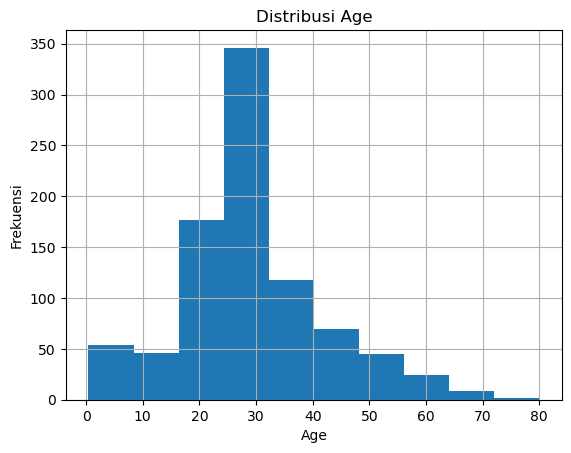

In [23]:
df["Age"].hist()
plt.title("Distribusi Age")
plt.xlabel("Age")
plt.ylabel("Frekuensi")
plt.show()

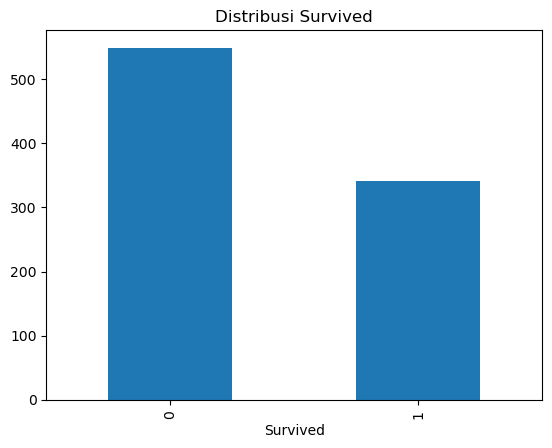

In [24]:
df["Survived"].value_counts().plot(kind="bar")
plt.title("Distribusi Survived")
plt.show()